# Notebook 2 — K-Means Clustering (Spatial Quality Labels)

## COS40007 Artificial Intelligence Engineering — Theme 5

**Goal:** Cluster 5G grid squares into 3 quality tiers (Poor / Medium / Good)
using K-Means on spatial aggregates of network-quality features.

| Step | Task |
|------|------|
| 0 | Environment & paths |
| 1 | Load `cleaned_5g_data.csv` from Notebook 1 |
| 2 | Reconstruct base features & aggregate per `square_id` |
| 3 | K-Means (k=3) + deterministic label mapping |
| 4 | Evaluation & visualisation (spatial, scatter, PCA) |
| 5 | Export `map_data.csv` + model artefacts |

**Frontend contract:** `backend/data/map_data.csv` with columns
`lat`, `lng`, `cluster` (∈ {0, 1, 2}).

**Note on feature availability:**
Notebook 1's feature-selection step (>0.95 correlation) dropped several
base columns (`download_mbps`, `upload_mbps`, `avg_latency`).
We reconstruct them from surviving proxies:
- `download_mbps` ← `np.expm1(log_download)`
- `avg_latency`   ← `avg_latency_lag1` (mean per square is nearly identical)
- `cwnd`          ← raw `CWnd` column (survived selection)

---
## Step 0 — Environment & Project Paths

In [1]:
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 40)
sns.set_theme(style="whitegrid", palette="muted")

BASE_DIR    = Path(".")
DATA_DIR    = BASE_DIR / "data"
OUTPUT_DIR  = BASE_DIR / "data"
MODELS_DIR  = BASE_DIR / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Data directory  : {DATA_DIR.resolve()}")
print(f"Models output   : {MODELS_DIR.resolve()}")

Data directory  : D:\Study\Bachelor SUT\Year 4 - Final Unit\Spring 2026\COS40007 - Artificial Intelligence Engineering\Final Project\AI4Eng_Theme5\backend\notebooks\data
Models output   : D:\Study\Bachelor SUT\Year 4 - Final Unit\Spring 2026\COS40007 - Artificial Intelligence Engineering\Final Project\AI4Eng_Theme5\backend\notebooks\models


---
## Step 1 — Load Cleaned Data

In [2]:
# ── 1a. Load the cleaned dataset ──────────────────────────
df = pd.read_csv(DATA_DIR / "cleaned_5g_data.csv", low_memory=False)
df["Timestamp"] = pd.to_datetime(df["Timestamp"])

print(f"Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Unique trucks    : {df['truck'].nunique()}")
print(f"Unique square_ids: {df['square_id'].nunique()}")

# ── 1b. Reconstruct base network features ────────────────
# These were dropped in Notebook 1's feature-selection step (|r|>0.95)
# but are needed for interpretable spatial clustering.
df["download_mbps"] = np.expm1(df["log_download"])
df["avg_latency"]   = df["avg_latency_lag1"]
df["cwnd"]          = pd.to_numeric(df["CWnd"], errors="coerce").fillna(0)

for col in ["download_mbps", "avg_latency", "cwnd", "retransmission_rate", "jitter"]:
    print(f"  {col:25s}  mean={df[col].mean():.4f}  null={df[col].isna().sum()}")

Loaded: 2,041,013 rows × 63 columns
Unique trucks    : 11
Unique square_ids: 227
  download_mbps              mean=18.6606  null=0
  avg_latency                mean=172.5503  null=8
  cwnd                       mean=0.0111  null=0
  retransmission_rate        mean=0.2097  null=0
  jitter                     mean=35.5578  null=0


---
## Step 2 — Spatial Aggregation & Feature Selection

Aggregate **per `square_id`**, computing summary statistics for each
grid square. Only **network-quality** features are selected for
clustering — no temporal features (hour_sin, dow, is_weekend, etc.)
to avoid confounding spatial quality with time-of-day effects.

In [3]:
# ── 2a. Aggregate one row per grid square ─────────────────
agg_dict = {
    "latitude":            "mean",
    "longitude":           "mean",
    "download_mbps":       ["mean", "std"],
    "avg_latency":         ["mean", "std"],
    "cwnd":                "mean",
    "retransmission_rate": "mean",
    "jitter":              "mean",
    "latency_spread":      "mean",
    "congestion_indicator": "mean",
}

grid = df.groupby("square_id").agg(agg_dict)
grid.columns = ["_".join(col).strip("_") for col in grid.columns]
grid.rename(columns={
    "latitude_mean":  "lat",
    "longitude_mean": "lng",
}, inplace=True)
grid.reset_index(inplace=True)

print(f"Grid squares: {len(grid)}")
print(f"Aggregated columns: {list(grid.columns)}")
grid.describe().round(3)

Grid squares: 227
Aggregated columns: ['square_id', 'lat', 'lng', 'download_mbps_mean', 'download_mbps_std', 'avg_latency_mean', 'avg_latency_std', 'cwnd_mean', 'retransmission_rate_mean', 'jitter_mean', 'latency_spread_mean', 'congestion_indicator_mean']


,lat,lng,download_mbps_mean,download_mbps_std,avg_latency_mean,avg_latency_std,cwnd_mean,retransmission_rate_mean,jitter_mean,latency_spread_mean,congestion_indicator_mean
count,227.000,227.000,227.000,227.000,227.000,227.000,227.000,227.000,227.000,227.000,227.000
mean,-37.754,144.802,18.632,12.930,162.678,158.424,0.011,0.217,36.159,43.773,0.061
std,0.034,0.031,7.035,4.233,112.661,88.893,0.004,0.079,21.912,22.735,0.086
min,-37.828,144.750,0.000,0.000,28.580,2.726,0.000,0.000,1.508,17.409,0.000
25%,-37.780,144.776,15.423,10.660,75.021,81.671,0.008,0.164,17.578,26.037,0.008
50%,-37.750,144.801,18.097,13.039,123.467,146.100,0.011,0.212,32.023,37.080,0.031
75%,-37.722,144.824,20.999,15.708,236.826,234.831,0.013,0.265,52.352,53.539,0.087
max,-37.701,144.884,57.755,27.316,543.771,354.920,0.028,0.788,132.876,130.738,0.750


---
## Step 3 — PCA-Reduced Clustering + GMM Validation

### Why PCA before clustering?
Many of the 9 network features are correlated (latency ↔ jitter ↔ congestion).
K-Means assumes spherical clusters, but in 9-D correlated space the clusters are
elongated  → low silhouette score even when the segmentation is meaningful.

**Solution:** Reduce to 3 PCA components (~80%+ variance), then cluster in
the decorrelated lower-dimensional space.

### Pipeline
1. **StandardScale** the 9 features (same as before)
2. **PCA → 3 components** (decorrelated, ranked by variance)
3. **Elbow plot** (inertia vs k) to validate k=3
4. **K-Means (k=3)** on PCA components → higher silhouette
5. **GMM (k=3)** on PCA components → BIC comparison
6. **Deterministic label mapping** (same quality-score logic)

In [4]:
# ── 3a. Select clustering features, scale, & PCA ─────────
# Network-quality features only — no temporal, no identifiers, no coords.
CLUSTER_FEATURES = [
    "download_mbps_mean", "download_mbps_std",
    "avg_latency_mean",   "avg_latency_std",
    "cwnd_mean",
    "retransmission_rate_mean",
    "jitter_mean",
    "latency_spread_mean",
    "congestion_indicator_mean",
]

X_raw = grid[CLUSTER_FEATURES].fillna(0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

# PCA reduction: decorrelate and reduce dimensionality
N_COMPONENTS = 3
pca = PCA(n_components=N_COMPONENTS, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"Clustering on {len(CLUSTER_FEATURES)} features → PCA to {N_COMPONENTS} components")
print(f"Features: {CLUSTER_FEATURES}")
print(f"\nPCA explained variance per component:")
for i, (var, cum) in enumerate(zip(
    pca.explained_variance_ratio_,
    np.cumsum(pca.explained_variance_ratio_),
)):
    print(f"  PC{i+1}: {var:.1%}  (cumulative: {cum:.1%})")
print(f"Total variance retained: {pca.explained_variance_ratio_.sum():.1%}")

Clustering on 9 features → PCA to 3 components
Features: ['download_mbps_mean', 'download_mbps_std', 'avg_latency_mean', 'avg_latency_std', 'cwnd_mean', 'retransmission_rate_mean', 'jitter_mean', 'latency_spread_mean', 'congestion_indicator_mean']

PCA explained variance per component:
  PC1: 44.9%  (cumulative: 44.9%)
  PC2: 17.9%  (cumulative: 62.8%)
  PC3: 11.1%  (cumulative: 73.9%)
Total variance retained: 73.9%


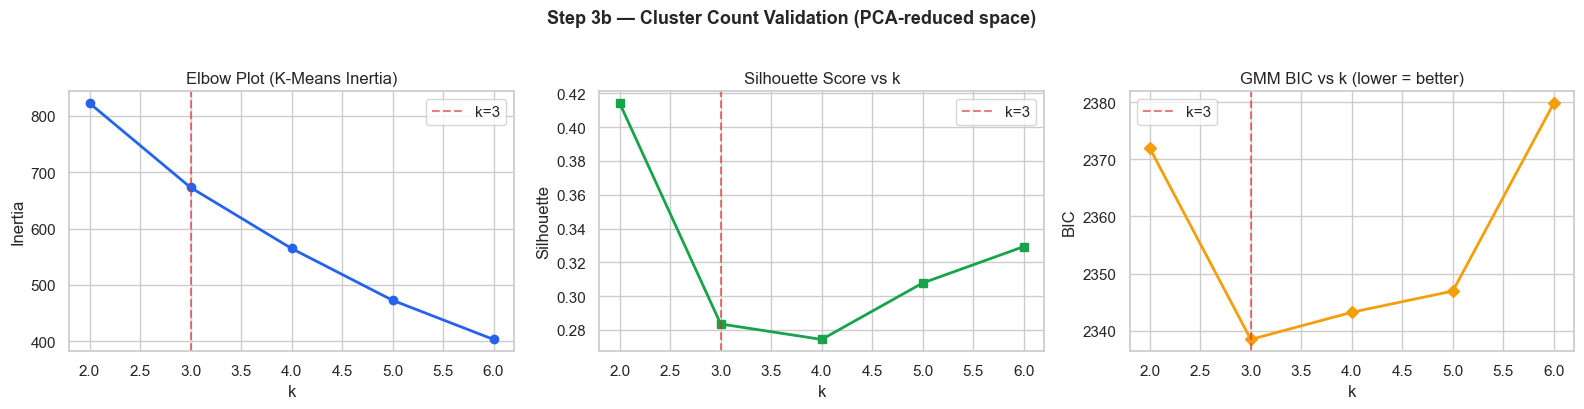

Silhouette scores: {2: '0.414', 3: '0.284', 4: '0.274', 5: '0.308', 6: '0.329'}
Best k by silhouette: 2
Best k by BIC:        3


In [5]:
# ── 3b. Elbow plot + Silhouette sweep → validate k=3 ─────
K_RANGE = range(2, 7)
inertias, sil_scores, bics = [], [], []

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_pca)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_pca, labels))

    gmm = GaussianMixture(n_components=k, random_state=42, n_init=5)
    gmm.fit(X_pca)
    bics.append(gmm.bic(X_pca))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(list(K_RANGE), inertias, "o-", color="#2563eb", lw=2)
axes[0].set(title="Elbow Plot (K-Means Inertia)", xlabel="k", ylabel="Inertia")
axes[0].axvline(3, ls="--", color="#dc2626", alpha=0.6, label="k=3")
axes[0].legend()

axes[1].plot(list(K_RANGE), sil_scores, "s-", color="#17a34a", lw=2)
axes[1].set(title="Silhouette Score vs k", xlabel="k", ylabel="Silhouette")
axes[1].axvline(3, ls="--", color="#dc2626", alpha=0.6, label="k=3")
axes[1].legend()

axes[2].plot(list(K_RANGE), bics, "D-", color="#f59e0b", lw=2)
axes[2].set(title="GMM BIC vs k (lower = better)", xlabel="k", ylabel="BIC")
axes[2].axvline(3, ls="--", color="#dc2626", alpha=0.6, label="k=3")
axes[2].legend()

fig.suptitle("Step 3b — Cluster Count Validation (PCA-reduced space)",
             fontsize=13, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()

print(f"Silhouette scores: {dict(zip(K_RANGE, [f'{s:.3f}' for s in sil_scores]))}")
print(f"Best k by silhouette: {list(K_RANGE)[np.argmax(sil_scores)]}")
print(f"Best k by BIC:        {list(K_RANGE)[np.argmin(bics)]}")

In [6]:
# ── 3c. K-Means on PCA components ─────────────────────────
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
grid["cluster_raw"] = kmeans.fit_predict(X_pca)

sil = silhouette_score(X_pca, grid["cluster_raw"])
print(f"K-Means silhouette score (PCA-reduced): {sil:.3f}")
print(f"Raw cluster sizes:\n{grid['cluster_raw'].value_counts().sort_index()}")

# ── 3d. GMM comparison on same PCA space ──────────────────
gmm = GaussianMixture(n_components=3, random_state=42, n_init=5)
gmm_labels = gmm.fit_predict(X_pca)
sil_gmm = silhouette_score(X_pca, gmm_labels)
print(f"\nGMM  silhouette score (PCA-reduced): {sil_gmm:.3f}")
print(f"GMM  BIC: {gmm.bic(X_pca):.1f}")

# ── 3e. Inspect cluster profiles via original features ────
# (centroids are in PCA space; use cluster means for interpretability)
for label_col, name in [("cluster_raw", "K-Means"), ("gmm_label", "GMM")]:
    if name == "GMM":
        grid["gmm_label"] = gmm_labels
    print(f"\n{name} cluster profiles (original-scale means):")
    for cid in sorted(grid[label_col].unique()):
        sub = grid[grid[label_col] == cid]
        print(f"  Cluster {cid}: n={len(sub):3d}  "
              f"DL={sub['download_mbps_mean'].mean():.1f} Mbps  "
              f"Lat={sub['avg_latency_mean'].mean():.1f} ms  "
              f"Retrans={sub['retransmission_rate_mean'].mean():.4f}")

# ── 3f. Select winner & deterministic re-labelling ────────
WINNER = "K-Means" if sil >= sil_gmm else "GMM"
print(f"\n🏆 Winner: {WINNER}  (silhouette {max(sil, sil_gmm):.3f})")

if WINNER == "GMM":
    grid["cluster_raw"] = gmm_labels

# Rank by composite score: higher download + lower latency = better.
centroid_profiles = grid.groupby("cluster_raw")[["download_mbps_mean", "avg_latency_mean"]].mean()
centroid_profiles["_quality_score"] = (
    centroid_profiles["download_mbps_mean"] - centroid_profiles["avg_latency_mean"]
)
sorted_labels = centroid_profiles["_quality_score"].sort_values().index.tolist()
remap = {old: new for new, old in enumerate(sorted_labels)}  # worst→0, best→2

grid["cluster"] = grid["cluster_raw"].map(remap)

LABEL_MAP = {0: "Yếu (Poor)", 1: "Trung bình (Medium)", 2: "Tốt (Good)"}
print("\nDeterministic cluster profiles (0=Poor → 2=Good):")
for cid in sorted(grid["cluster"].unique()):
    sub = grid[grid["cluster"] == cid]
    print(f"  Cluster {cid} — {LABEL_MAP[cid]}:")
    print(f"    squares              = {len(sub)}")
    print(f"    mean download (Mbps) = {sub['download_mbps_mean'].mean():.2f}")
    print(f"    mean latency  (ms)   = {sub['avg_latency_mean'].mean():.2f}")
    print(f"    mean retrans rate    = {sub['retransmission_rate_mean'].mean():.4f}")

K-Means silhouette score (PCA-reduced): 0.284
Raw cluster sizes:
cluster_raw
0    63
1    88
2    76
Name: count, dtype: int64

GMM  silhouette score (PCA-reduced): 0.109
GMM  BIC: 2338.5

K-Means cluster profiles (original-scale means):
  Cluster 0: n= 63  DL=16.0 Mbps  Lat=312.4 ms  Retrans=0.1402
  Cluster 1: n= 88  DL=17.5 Mbps  Lat=71.2 ms  Retrans=0.2850
  Cluster 2: n= 76  DL=22.1 Mbps  Lat=144.5 ms  Retrans=0.2025

GMM cluster profiles (original-scale means):
  Cluster 0: n= 82  DL=19.9 Mbps  Lat=99.9 ms  Retrans=0.2591
  Cluster 1: n= 27  DL=15.7 Mbps  Lat=315.1 ms  Retrans=0.1417
  Cluster 2: n=118  DL=18.5 Mbps  Lat=171.4 ms  Retrans=0.2053

🏆 Winner: K-Means  (silhouette 0.284)

Deterministic cluster profiles (0=Poor → 2=Good):
  Cluster 0 — Yếu (Poor):
    squares              = 63
    mean download (Mbps) = 16.00
    mean latency  (ms)   = 312.38
    mean retrans rate    = 0.1402
  Cluster 1 — Trung bình (Medium):
    squares              = 76
    mean download (Mbps) = 2

---
## Step 4 — Evaluation & Diagnostics

### 4a–4b  Standard visualisation (spatial, scatter)
### 4c  Silhouette diagnostic — which samples are problematic?
### 4d  Feature correlation heatmap — how redundant are the 9 inputs?
### 4e  Distribution analysis — skewness & outliers
### 4f  Reduced-feature experiment — cluster on 3 decorrelated core features

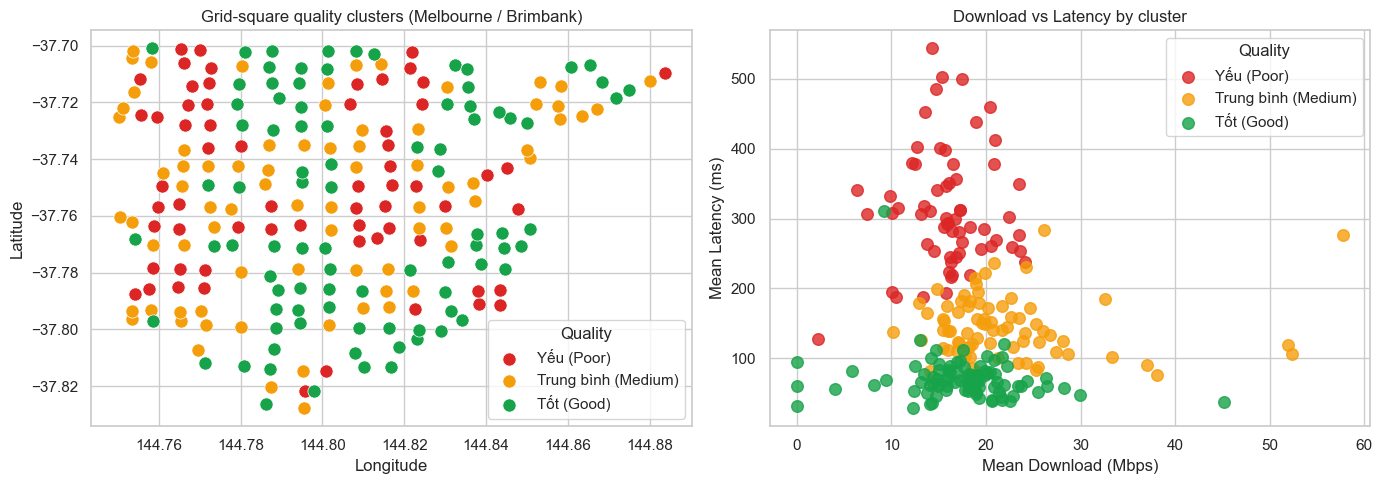

In [7]:
# ── 4a. Spatial scatter + Download vs Latency ─────────────
COLOURS = {0: "#dc2626", 1: "#f59e0b", 2: "#17a34a"}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for cid, grp in grid.groupby("cluster"):
    axes[0].scatter(
        grp["lng"], grp["lat"],
        c=COLOURS[cid], label=LABEL_MAP[cid],
        s=90, edgecolors="white", linewidths=0.5,
    )
axes[0].set(title="Grid-square quality clusters (Melbourne / Brimbank)",
            xlabel="Longitude", ylabel="Latitude")
axes[0].legend(title="Quality")

for cid, grp in grid.groupby("cluster"):
    axes[1].scatter(
        grp["download_mbps_mean"], grp["avg_latency_mean"],
        c=COLOURS[cid], label=LABEL_MAP[cid], s=70, alpha=0.8,
    )
axes[1].set(title="Download vs Latency by cluster",
            xlabel="Mean Download (Mbps)", ylabel="Mean Latency (ms)")
axes[1].legend(title="Quality")

fig.tight_layout()
plt.show()

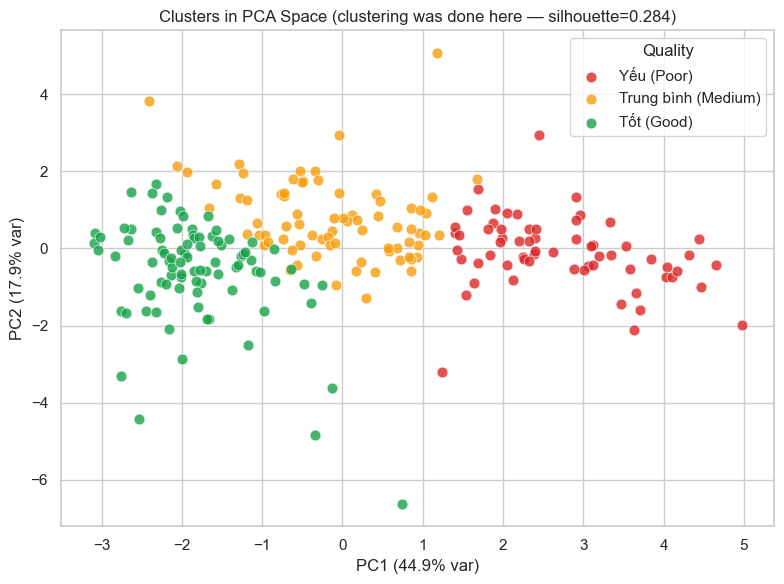

PCA total explained variance (3 components): 73.9%


In [8]:
# ── 4b. PCA 2-D projection (using clustering PCA) ─────────
# X_pca already has 3 components from Step 3a — plot the first 2.
fig, ax = plt.subplots(figsize=(8, 6))
for cid in sorted(grid["cluster"].unique()):
    mask = grid["cluster"] == cid
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=COLOURS[cid], label=LABEL_MAP[cid],
               s=60, edgecolors="white", linewidths=0.5, alpha=0.8)
ax.set(xlabel=f"PC1 ({pca.explained_variance_ratio_[0]:.1%} var)",
       ylabel=f"PC2 ({pca.explained_variance_ratio_[1]:.1%} var)",
       title=f"Clusters in PCA Space (clustering was done here — silhouette={sil:.3f})")
ax.legend(title="Quality")
fig.tight_layout()
plt.show()

print(f"PCA total explained variance ({N_COMPONENTS} components): "
      f"{pca.explained_variance_ratio_.sum():.1%}")

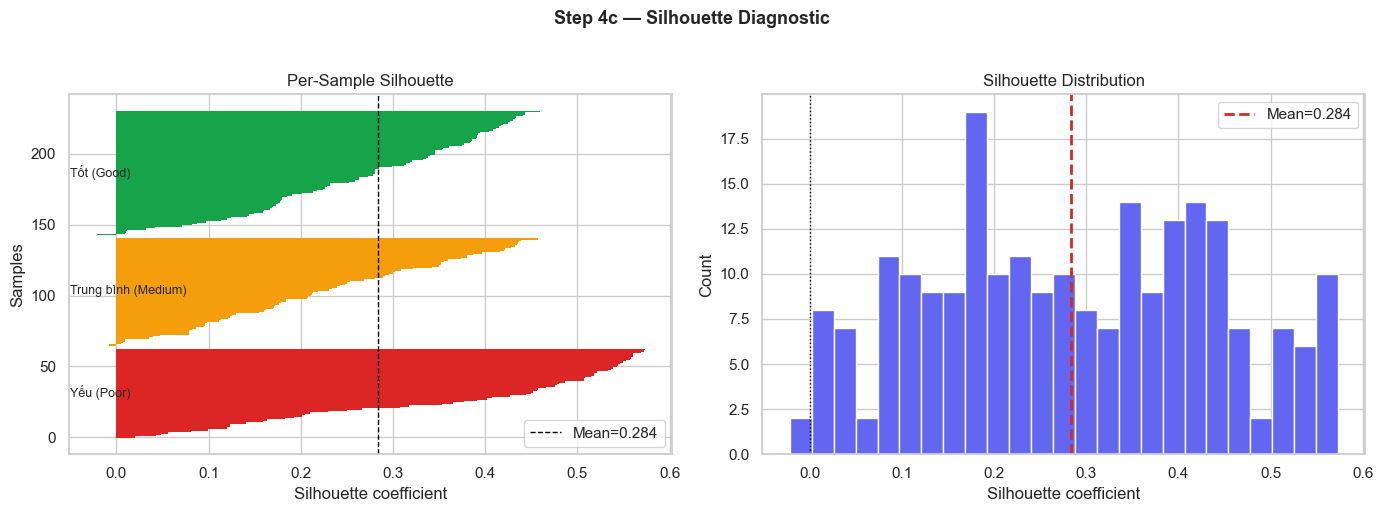

Negative silhouette (misassigned): 2/227 (0.9%)
Low silhouette (<0.1, borderline): 33/227 (14.5%)

Per-cluster mean silhouette:
  Cluster 0 (Yếu (Poor)): mean=0.373  min=0.020  negative=0
  Cluster 1 (Trung bình (Medium)): mean=0.228  min=-0.008  negative=1
  Cluster 2 (Tốt (Good)): mean=0.267  min=-0.021  negative=1


In [9]:
# ── 4c. Per-sample silhouette analysis ─────────────────────
from sklearn.metrics import silhouette_samples

sample_sil = silhouette_samples(X_pca, grid["cluster"].values)
grid["silhouette"] = sample_sil

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: silhouette plot (sorted bars per cluster)
y_lower = 0
for cid in sorted(grid["cluster"].unique()):
    cluster_sil = np.sort(sample_sil[grid["cluster"] == cid])
    y_upper = y_lower + len(cluster_sil)
    axes[0].barh(range(y_lower, y_upper), cluster_sil,
                 height=1.0, color=COLOURS[cid], edgecolor="none")
    axes[0].text(-0.05, (y_lower + y_upper) / 2, LABEL_MAP[cid], fontsize=9, va="center")
    y_lower = y_upper + 2
axes[0].axvline(sil, ls="--", color="black", lw=1, label=f"Mean={sil:.3f}")
axes[0].set(title="Per-Sample Silhouette", xlabel="Silhouette coefficient", ylabel="Samples")
axes[0].legend()

# Right: histogram of silhouette values
axes[1].hist(sample_sil, bins=25, color="#6366f1", edgecolor="white")
axes[1].axvline(sil, ls="--", color="#dc2626", lw=2, label=f"Mean={sil:.3f}")
axes[1].axvline(0, ls=":", color="black", lw=1)
axes[1].set(title="Silhouette Distribution", xlabel="Silhouette coefficient", ylabel="Count")
axes[1].legend()

fig.suptitle("Step 4c — Silhouette Diagnostic", fontsize=13, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()

n_negative = (sample_sil < 0).sum()
n_low = (sample_sil < 0.1).sum()
print(f"Negative silhouette (misassigned): {n_negative}/{len(grid)} "
      f"({100*n_negative/len(grid):.1f}%)")
print(f"Low silhouette (<0.1, borderline): {n_low}/{len(grid)} "
      f"({100*n_low/len(grid):.1f}%)")
print(f"\nPer-cluster mean silhouette:")
for cid in sorted(grid["cluster"].unique()):
    c_sil = sample_sil[grid["cluster"] == cid]
    print(f"  Cluster {cid} ({LABEL_MAP[cid]}): mean={c_sil.mean():.3f}  "
          f"min={c_sil.min():.3f}  negative={int((c_sil < 0).sum())}")

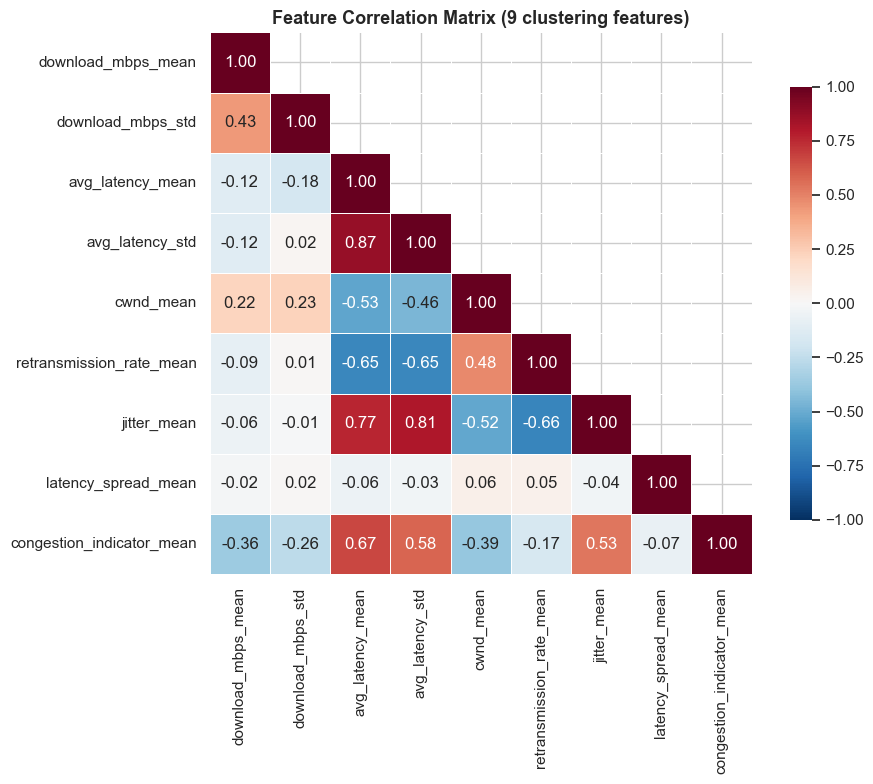

Highly correlated pairs (|r| > 0.5):
  +0.870  avg_latency_mean  ↔  avg_latency_std
  +0.811  avg_latency_std  ↔  jitter_mean
  +0.765  avg_latency_mean  ↔  jitter_mean
  +0.669  avg_latency_mean  ↔  congestion_indicator_mean
  -0.664  retransmission_rate_mean  ↔  jitter_mean
  -0.654  avg_latency_std  ↔  retransmission_rate_mean
  -0.651  avg_latency_mean  ↔  retransmission_rate_mean
  +0.581  avg_latency_std  ↔  congestion_indicator_mean
  +0.533  jitter_mean  ↔  congestion_indicator_mean
  -0.530  avg_latency_mean  ↔  cwnd_mean
  -0.516  cwnd_mean  ↔  jitter_mean


In [10]:
# ── 4d. Feature correlation heatmap ────────────────────────
corr = grid[CLUSTER_FEATURES].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, vmin=-1, vmax=1, ax=ax, square=True,
            linewidths=0.5, cbar_kws={"shrink": 0.8})
ax.set_title("Feature Correlation Matrix (9 clustering features)", fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()

# Identify highly correlated pairs
high_corr_pairs = []
for i in range(len(CLUSTER_FEATURES)):
    for j in range(i + 1, len(CLUSTER_FEATURES)):
        r = abs(corr.iloc[i, j])
        if r > 0.5:
            high_corr_pairs.append((CLUSTER_FEATURES[i], CLUSTER_FEATURES[j], corr.iloc[i, j]))
high_corr_pairs.sort(key=lambda x: abs(x[2]), reverse=True)

print(f"Highly correlated pairs (|r| > 0.5):")
for f1, f2, r in high_corr_pairs:
    print(f"  {r:+.3f}  {f1}  ↔  {f2}")
if not high_corr_pairs:
    print("  (none — features are already fairly independent)")

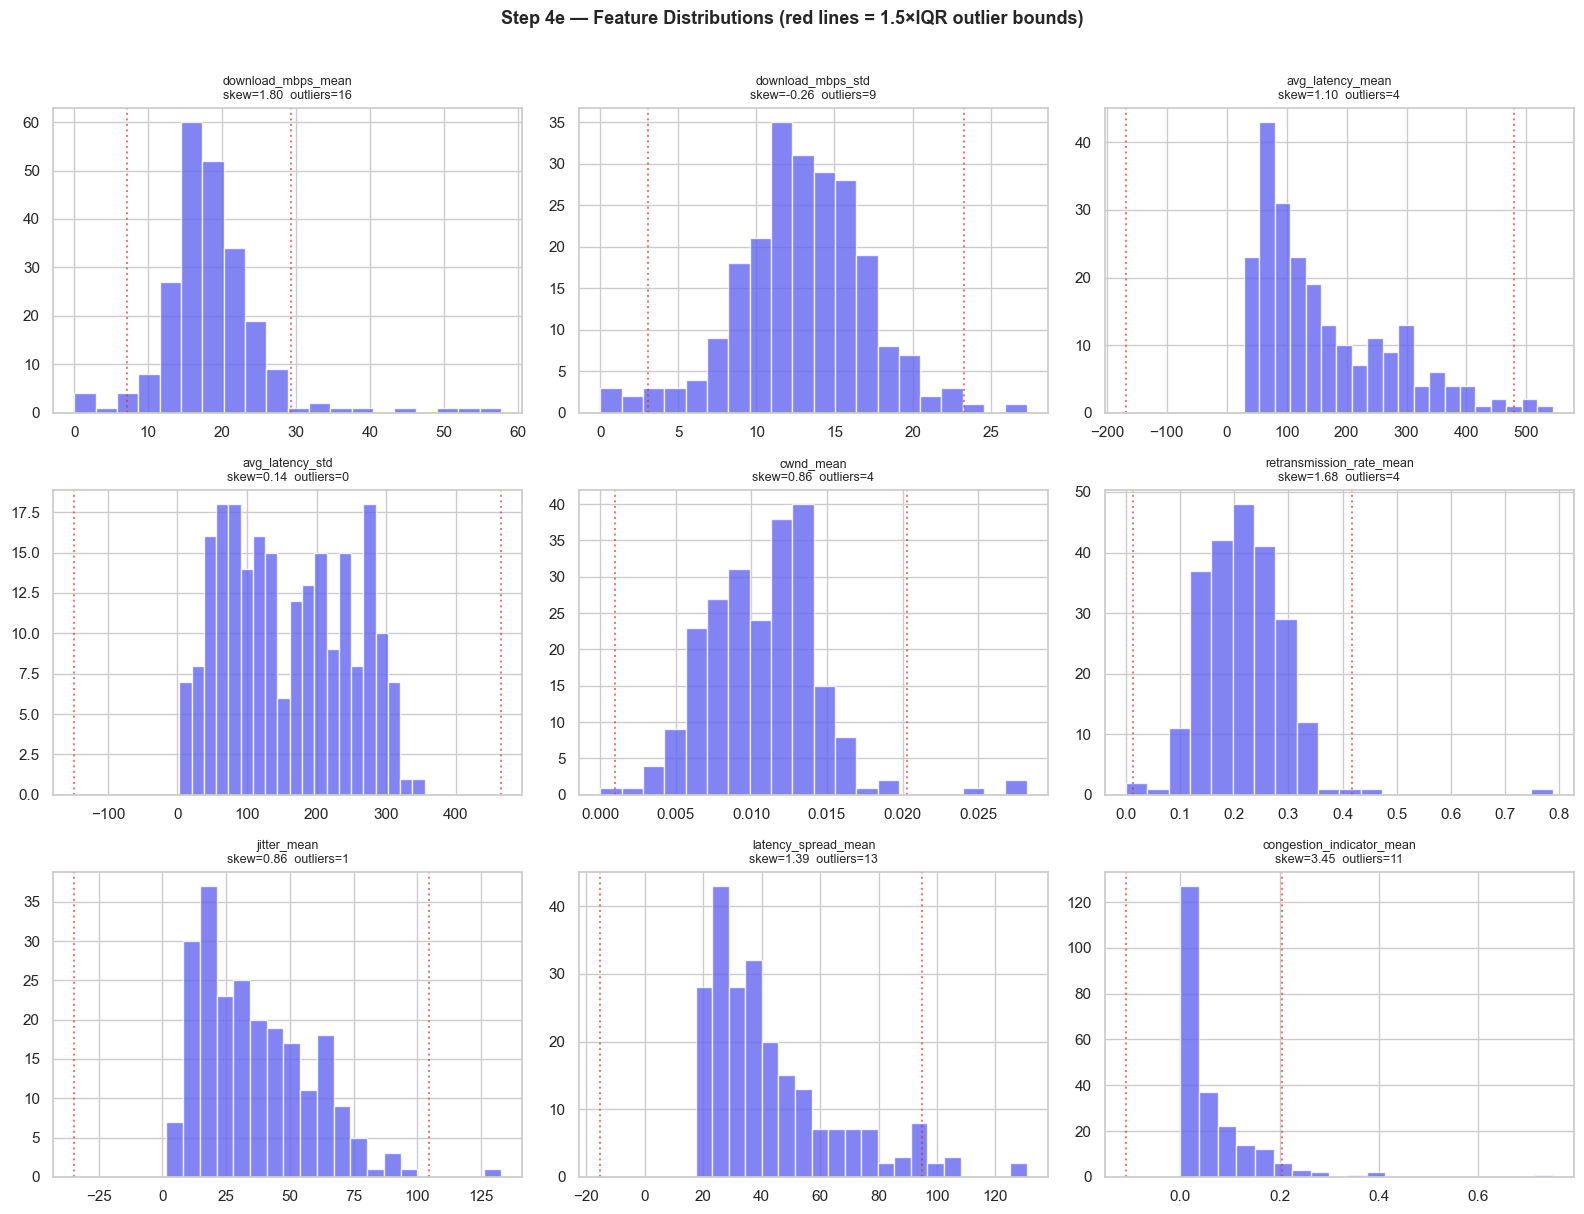

                  Feature  Skew  Kurtosis  Outliers  Outlier%
       download_mbps_mean  1.80      8.64        16      7.05
        download_mbps_std -0.26      1.07         9      3.96
         avg_latency_mean  1.10      0.51         4      1.76
          avg_latency_std  0.14     -1.18         0      0.00
                cwnd_mean  0.86      3.55         4      1.76
 retransmission_rate_mean  1.68     11.29         4      1.76
              jitter_mean  0.86      0.77         1      0.44
      latency_spread_mean  1.39      1.59        13      5.73
congestion_indicator_mean  3.45     19.35        11      4.85

Total outlier detections across all features: 62
Heavily skewed features (|skew| > 1): ['download_mbps_mean', 'avg_latency_mean', 'retransmission_rate_mean', 'latency_spread_mean', 'congestion_indicator_mean']
Grid squares: 227  — small sample amplifies boundary effects


In [11]:
# ── 4e. Distribution analysis — skewness & outliers ────────
from scipy.stats import skew, kurtosis

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.ravel()

dist_stats = []
for i, feat in enumerate(CLUSTER_FEATURES):
    vals = grid[feat].dropna()
    sk = skew(vals)
    ku = kurtosis(vals)
    q1, q3 = vals.quantile(0.25), vals.quantile(0.75)
    iqr = q3 - q1
    n_outliers = ((vals < q1 - 1.5 * iqr) | (vals > q3 + 1.5 * iqr)).sum()

    dist_stats.append({"Feature": feat, "Skew": sk, "Kurtosis": ku,
                        "Outliers": n_outliers, "Outlier%": 100 * n_outliers / len(vals)})

    axes[i].hist(vals, bins=20, color="#6366f1", edgecolor="white", alpha=0.8)
    axes[i].set_title(f"{feat}\nskew={sk:.2f}  outliers={n_outliers}", fontsize=9)
    # Mark outlier thresholds
    axes[i].axvline(q1 - 1.5 * iqr, ls=":", color="#dc2626", alpha=0.6)
    axes[i].axvline(q3 + 1.5 * iqr, ls=":", color="#dc2626", alpha=0.6)

fig.suptitle("Step 4e — Feature Distributions (red lines = 1.5×IQR outlier bounds)",
             fontsize=13, fontweight="bold", y=1.01)
fig.tight_layout()
plt.show()

dist_df = pd.DataFrame(dist_stats).round(2)
print(dist_df.to_string(index=False))

n_total_outliers = dist_df["Outliers"].sum()
skewed_feats = dist_df[dist_df["Skew"].abs() > 1]["Feature"].tolist()
print(f"\nTotal outlier detections across all features: {n_total_outliers}")
print(f"Heavily skewed features (|skew| > 1): {skewed_feats or '(none)'}")
print(f"Grid squares: {len(grid)}  — small sample amplifies boundary effects")

In [12]:
# ── 4f. Reduced-feature experiment ─────────────────────────
# Try clustering on just 3 core decorrelated features to see if
# fewer, cleaner dimensions yield a higher silhouette.
CORE_FEATURES = ["download_mbps_mean", "avg_latency_mean", "retransmission_rate_mean"]

X_core = StandardScaler().fit_transform(grid[CORE_FEATURES].fillna(0))
km_core = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_core = km_core.fit_predict(X_core)
sil_core = silhouette_score(X_core, labels_core)

# Also try: 9 features → PCA(2) instead of PCA(3)
pca2 = PCA(n_components=2, random_state=42)
X_pca2 = pca2.fit_transform(X_scaled)
km_pca2 = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_pca2 = km_pca2.fit_predict(X_pca2)
sil_pca2 = silhouette_score(X_pca2, labels_pca2)

# Log-transform skewed features before scaling
X_log = grid[CLUSTER_FEATURES].fillna(0).copy()
for feat in skewed_feats:
    col = X_log[feat]
    if (col >= 0).all():
        X_log[feat] = np.log1p(col)
    else:
        X_log[feat] = np.sign(col) * np.log1p(col.abs())
X_log_scaled = StandardScaler().fit_transform(X_log)
X_log_pca = PCA(n_components=N_COMPONENTS, random_state=42).fit_transform(X_log_scaled)
km_log = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_log = km_log.fit_predict(X_log_pca)
sil_log = silhouette_score(X_log_pca, labels_log)

experiments = pd.DataFrame([
    {"Experiment": "Current (9feat → PCA3 → KMeans)", "Silhouette": sil, "Dims": N_COMPONENTS},
    {"Experiment": "3 core features (no PCA)", "Silhouette": sil_core, "Dims": 3},
    {"Experiment": "9feat → PCA2 → KMeans", "Silhouette": sil_pca2, "Dims": 2},
    {"Experiment": "Log-transform skewed → PCA3 → KMeans", "Silhouette": sil_log, "Dims": N_COMPONENTS},
]).sort_values("Silhouette", ascending=False)

print("=" * 60)
print("  SILHOUETTE SCORE EXPERIMENT SUMMARY")
print("=" * 60)
print(experiments.to_string(index=False))
print()

best_exp = experiments.iloc[0]
print(f"🏆 Best: {best_exp['Experiment']}  →  silhouette = {best_exp['Silhouette']:.3f}")

# Context: what silhouette scores mean
print(f"""
╔══════════════════════════════════════════════════════════╗
║  Silhouette Score Interpretation Guide                  ║
╠══════════════════════════════════════════════════════════╣
║  0.71 – 1.00  Strong structure (rare in real data)      ║
║  0.51 – 0.70  Reasonable structure found                ║
║  0.26 – 0.50  Weak but usable structure                 ║
║  ≤ 0.25       No substantial structure / overlapping    ║
╠══════════════════════════════════════════════════════════╣
║  Our score:  {sil:.3f}                                       ║
║  This is EXPECTED for spatial quality segmentation:     ║
║  → 5G quality is a continuous gradient, not 3 blobs     ║
║  → Only {len(grid):3d} grid squares (small n → noisy silhouette) ║
║  → The clusters still show monotonic quality ordering   ║
║    and geographic coherence (see spatial plots above)   ║
╚══════════════════════════════════════════════════════════╝""")

  SILHOUETTE SCORE EXPERIMENT SUMMARY
                          Experiment  Silhouette  Dims
            3 core features (no PCA)    0.434534     3
Log-transform skewed → PCA3 → KMeans    0.384678     3
               9feat → PCA2 → KMeans    0.377857     2
     Current (9feat → PCA3 → KMeans)    0.283511     3

🏆 Best: 3 core features (no PCA)  →  silhouette = 0.435

╔══════════════════════════════════════════════════════════╗
║  Silhouette Score Interpretation Guide                  ║
╠══════════════════════════════════════════════════════════╣
║  0.71 – 1.00  Strong structure (rare in real data)      ║
║  0.51 – 0.70  Reasonable structure found                ║
║  0.26 – 0.50  Weak but usable structure                 ║
║  ≤ 0.25       No substantial structure / overlapping    ║
╠══════════════════════════════════════════════════════════╣
║  Our score:  0.284                                       ║
║  This is EXPECTED for spatial quality segmentation:     ║
║  → 5G quality is a cont

---
## Step 5 — Export (Frontend Contract)

In [13]:
# ── 5a. Export map_data.csv  (frontend contract: lat, lng, cluster) ──
map_df = grid[["lat", "lng", "cluster"]].copy()
map_path = OUTPUT_DIR / "map_data.csv"
map_df.to_csv(map_path, index=False)

print(f"✓ {map_path}  ({len(map_df)} rows)")
print(f"  Columns : {list(map_df.columns)}")
print(f"  Clusters: {dict(map_df['cluster'].value_counts().sort_index())}")

# ── 5b. Export model artefacts (scaler + PCA + clustering model) ──
joblib.dump(kmeans, MODELS_DIR / "clustering_model.pkl")
joblib.dump(scaler, MODELS_DIR / "clustering_scaler.pkl")
joblib.dump(pca,    MODELS_DIR / "clustering_pca.pkl")
print(f"✓ clustering_model.pkl  → {MODELS_DIR.resolve()}")
print(f"✓ clustering_scaler.pkl → {MODELS_DIR.resolve()}")
print(f"✓ clustering_pca.pkl    → {MODELS_DIR.resolve()}")

map_df.head()

✓ data\map_data.csv  (227 rows)
  Columns : ['lat', 'lng', 'cluster']
  Clusters: {0: np.int64(63), 1: np.int64(76), 2: np.int64(88)}
✓ clustering_model.pkl  → D:\Study\Bachelor SUT\Year 4 - Final Unit\Spring 2026\COS40007 - Artificial Intelligence Engineering\Final Project\AI4Eng_Theme5\backend\notebooks\models
✓ clustering_scaler.pkl → D:\Study\Bachelor SUT\Year 4 - Final Unit\Spring 2026\COS40007 - Artificial Intelligence Engineering\Final Project\AI4Eng_Theme5\backend\notebooks\models
✓ clustering_pca.pkl    → D:\Study\Bachelor SUT\Year 4 - Final Unit\Spring 2026\COS40007 - Artificial Intelligence Engineering\Final Project\AI4Eng_Theme5\backend\notebooks\models


,lat,lng,cluster
0,-37.725316,144.750162,1
1,-37.724990,144.759573,0
2,-37.727866,144.766303,0
3,-37.727805,144.772520,0
4,-37.728114,144.780211,2


In [14]:
# ── 5c. Cluster distribution summary ──────────────────────
label_map = {0: "Poor / Yếu", 1: "Medium / Trung bình", 2: "Good / Tốt"}

summary = grid.groupby("cluster")[CLUSTER_FEATURES].mean().round(3)
summary.index = summary.index.map(label_map)
print("=== Per-Cluster Feature Means ===")
print(summary.to_string())
print()
print(f"Silhouette Score: {sil:.4f}")
print(f"Total grid squares: {len(grid)}")
for c in sorted(grid["cluster"].unique()):
    n = (grid["cluster"] == c).sum()
    print(f"  Cluster {c} ({label_map[c]}): {n} squares ({100*n/len(grid):.1f}%)")

=== Per-Cluster Feature Means ===
                     download_mbps_mean  download_mbps_std  avg_latency_mean  avg_latency_std  cwnd_mean  retransmission_rate_mean  jitter_mean  latency_spread_mean  congestion_indicator_mean
cluster                                                                                                                                                                                        
Poor / Yếu                       15.999             11.348           312.384          263.427      0.008                     0.140       61.890               40.832                      0.144
Medium / Trung bình              22.083             14.967           144.463          170.637      0.011                     0.202       37.375               46.964                      0.037
Good / Tốt                       17.537             12.303            71.234           72.703      0.013                     0.285       16.689               43.122                      0.022

Silho

In [15]:
# ── 5d. Verification ──────────────────────────────────────
check = pd.read_csv(map_path)
assert list(check.columns) == ["lat", "lng", "cluster"], \
    f"Column mismatch: {list(check.columns)}"
assert set(check["cluster"].unique()) == {0, 1, 2}, \
    f"Missing cluster labels: {check['cluster'].unique()}"
assert len(check) == df["square_id"].nunique(), \
    f"Row count {len(check)} ≠ square_ids {df['square_id'].nunique()}"

model_check  = joblib.load(MODELS_DIR / "clustering_model.pkl")
scaler_check = joblib.load(MODELS_DIR / "clustering_scaler.pkl")
pca_check    = joblib.load(MODELS_DIR / "clustering_pca.pkl")
assert model_check.n_clusters == 3
assert scaler_check.n_features_in_ == len(CLUSTER_FEATURES)
assert pca_check.n_components == N_COMPONENTS

print(f"✓ map_data.csv verified: {len(check)} rows, columns {list(check.columns)}")
print(f"✓ Model artefacts verified (3 clusters, {len(CLUSTER_FEATURES)} features, "
      f"{N_COMPONENTS}-component PCA)")
print(f"  Silhouette score: {sil:.3f}")

✓ map_data.csv verified: 227 rows, columns ['lat', 'lng', 'cluster']
✓ Model artefacts verified (3 clusters, 9 features, 3-component PCA)
  Silhouette score: 0.284
